In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split

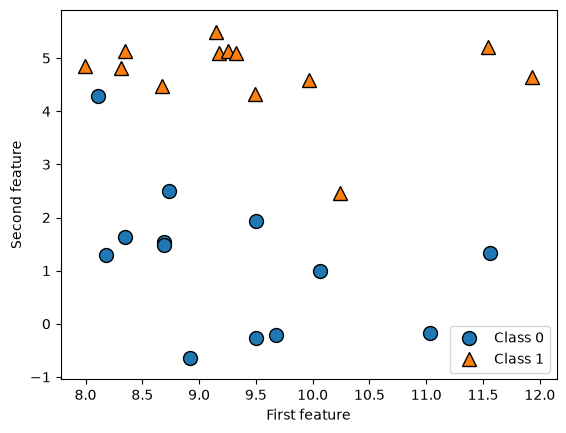

X.shape:(26, 2)


In [59]:
#２クラス分類データセットの例
x,y = mglearn.datasets.make_forge()
mglearn.discrete_scatter(x[:,0],x[:,1],y)
plt.legend(["Class 0","Class 1"],loc=4) #凡例を示す loc=4は右下に表示することを意味する
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()
print("X.shape:{}".format(x.shape))

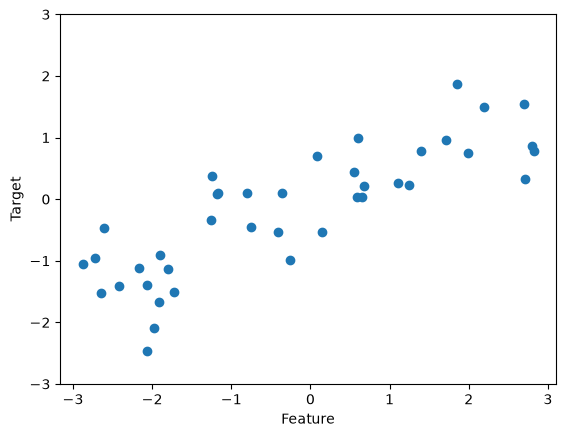

In [60]:
#連続値の特徴量を持つ回帰データセットの例
x,y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(x,y,"o")
plt.ylim(-3,3)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()

In [61]:
#乳がんデータセットをロード
#Bunch型

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
print("cancer.keys:{}".format(cancer.keys()))


cancer.keys:dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [62]:
print("cnacer shape:{}".format(cancer.data.shape))

cnacer shape:(569, 30)


In [63]:
# np.bincount()：0, 1, 2... がそれぞれ何個あるかを数える
# 例：[0, 1, 1, 0, 1] → [2, 3]（0が2個、1が3個）

# zip()：複数のデータから、同じ位置の要素同士を組み合わせる
# 例：["A", "B"] と [10, 20] → ("A", 10), ("B", 20)

# 辞書内包表記で対応させたものを辞書にする
# {"malignant": 212, "benign": 357}

print("Sample counts per class:\n{}".format(
    {n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))}
))

Sample counts per class:
{np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [64]:
#特徴量の確認
print("Feature names:\n{}".format(cancer.feature_names))

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [65]:
#実世界の回帰データセット
from sklearn.utils import Bunch

def load_boston():
    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]
    feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
        'TAX', 'PTRATIO', 'B', 'LSTAT']
    return Bunch(data=data, target=target, feature_names=np.array(feature_names))

boston = load_boston()
print("Data shape:{}".format(boston.data.shape))

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\seita\AppData\Local\Temp\ipykernel_1232\4226439148.py:6: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Data shape:(506, 13)


In [66]:
#特徴量間の積(交互作用)も含めたデータセットを作成
#非線形な特徴量を追加して、線形モデルの表現力を上げる
x,y = mglearn.datasets.load_extended_boston()
print("X.shape:{}".format(x.shape))

X.shape:(506, 104)


## K-最近傍法

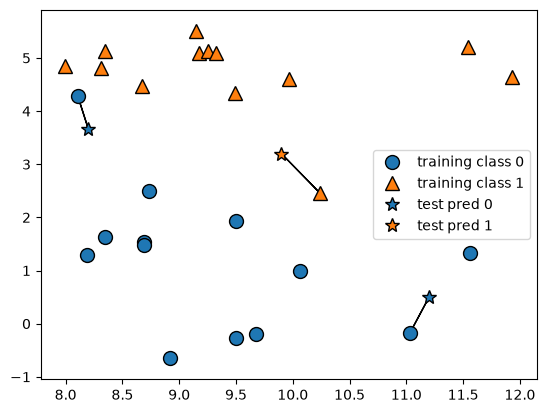

In [67]:
#forgeデータセットのk-最近傍法の分類器の決定境界を可視化
mglearn.plots.plot_knn_classification(n_neighbors=1)

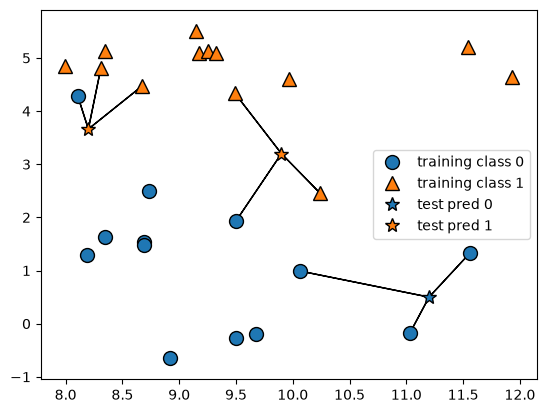

In [68]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

In [69]:
from sklearn.neighbors import KNeighborsClassifier

x,y = mglearn.datasets.make_forge()

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    random_state=0
)

clf = KNeighborsClassifier(
    n_neighbors=3
)

clf.fit(x_train,y_train)

print("Test set predictions:{}".format(clf.predict(x_test)))


Test set predictions:[1 0 1 0 1 0 0]


In [70]:
print("Test set accuracy:{:.2f}".format(clf.score(x_test,y_test)))

Test set accuracy:0.86


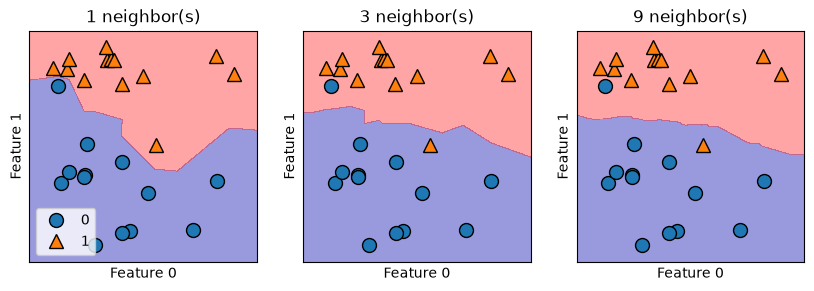

In [71]:
#kが1,3,9の時の決定境界を描画
#kが小さいほど個々の訓練データの影響を強く受けて複雑な決定境界になりやすい
fig,axes = plt.subplots(1,3,figsize=(10,3))
for n_neighbors,ax in zip([1,3,9],axes):
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(x,y)
    mglearn.plots.plot_2d_separator(clf,x,fill=True,eps=0.5,ax=ax,alpha=.4)
    mglearn.discrete_scatter(x[:,0],x[:,1],y,ax=ax)
    ax.set_title("{} neighbor(s)".format(n_neighbors))
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
axes[0].legend(loc=3)

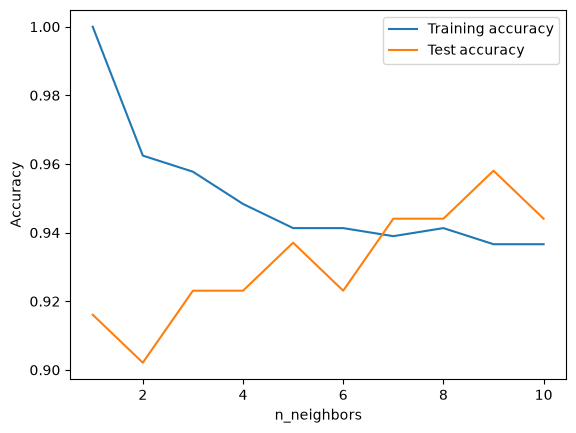

In [72]:
#モデルの複雑さと汎化性能の関係を確認
x_train,x_test,y_train,y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=0
)

training_accuracy = []
test_accuracy = []
neighbors_settings = range(1,11)

#nを１から１０まで変化させて試す
for n_neighbors in neighbors_settings:
    #モデル構築
    clf = KNeighborsClassifier(
        n_neighbors=n_neighbors
    )
    clf.fit(x_train,y_train)
    #訓練セット精度を記録
    training_accuracy.append(clf.score(x_train,y_train))
    #汎化精度を記録
    test_accuracy.append(clf.score(x_test,y_test))

plt.plot(neighbors_settings,training_accuracy,label="Training accuracy")
plt.plot(neighbors_settings,test_accuracy,label="Test accuracy")
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.legend()

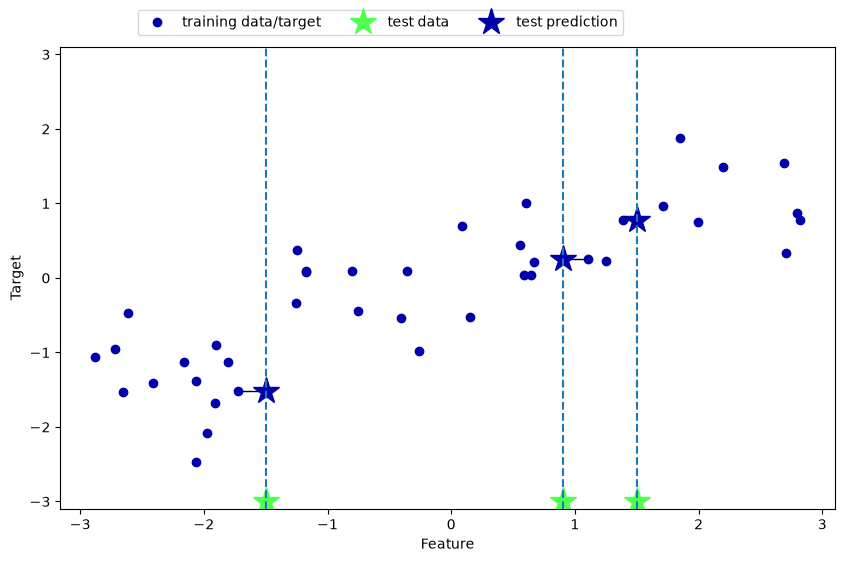

In [73]:
#k-最近傍回帰
mglearn.plots.plot_knn_regression(n_neighbors=1)

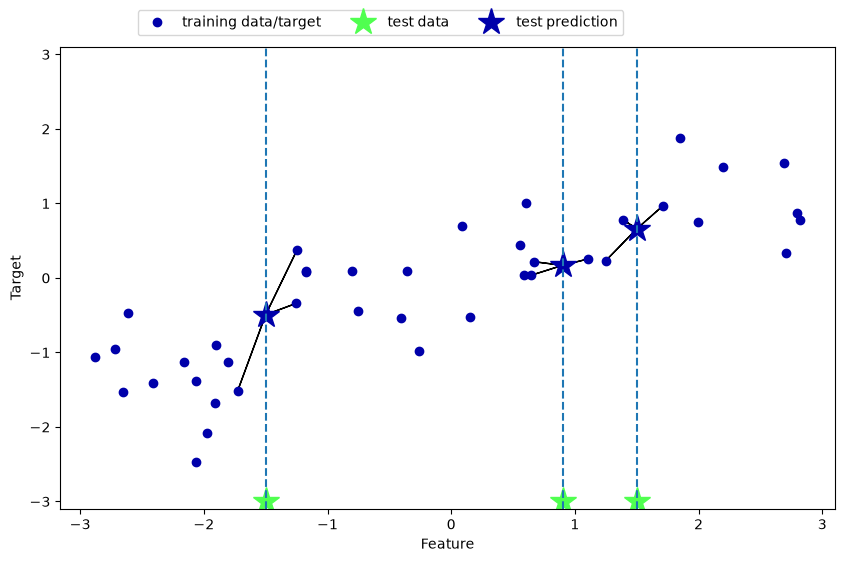

In [74]:
mglearn.plots.plot_knn_regression(n_neighbors=3)

In [75]:
from sklearn.neighbors import KNeighborsRegressor

x,y = mglearn.datasets.make_wave(n_samples=40)

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    random_state=0
)

reg = KNeighborsRegressor(n_neighbors=3)
reg.fit(x_train,y_train)

print("Test set predictions:\n{}".format(reg.predict(x_test)))

Test set predictions:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [76]:
#回帰モデルの場合は、scoreメソッドは決定係数R^2を返す
print(("Test set R^2:{:.2f}".format(reg.score(x_test,y_test))))

Test set R^2:0.83


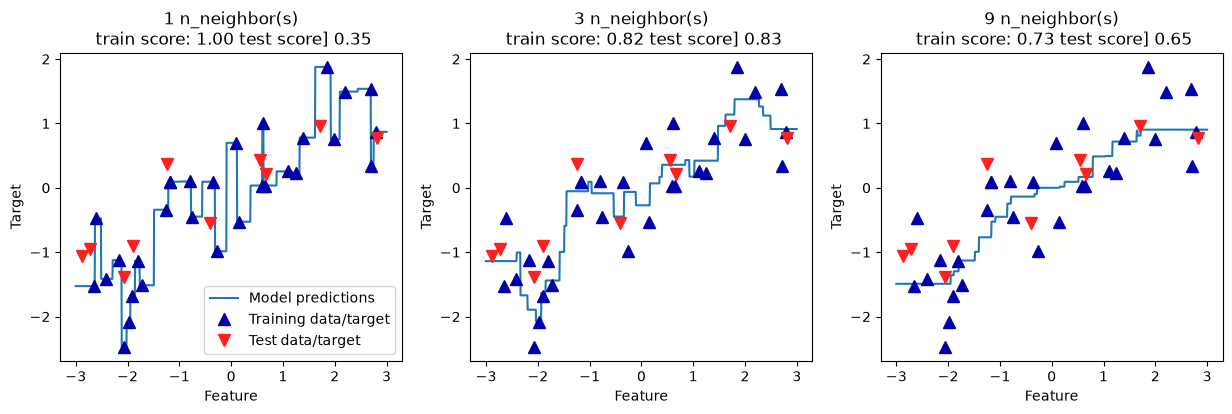

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# -3~3までの間に1000点のデータポイントを作る
line = np.linspace(-3, 3, 1000).reshape(-1, 1)
for n_neighbors, ax in zip([1, 3, 9], axes):
    # 1, 3, 9近傍点で予測
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(x_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(x_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(x_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)
    
    ax.set_title(
        "{} n_neighbor(s)\n train score: {:.2f} test score] {:.2f}".format(
            n_neighbors, reg.score(x_train, y_train),
            reg.score(x_test, y_test))
    )
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target", "Test data/target"], loc="best") #グラフを書いた順番
plt.show()

## 線形モデル

w[0]: 0.393906  b: -0.031804


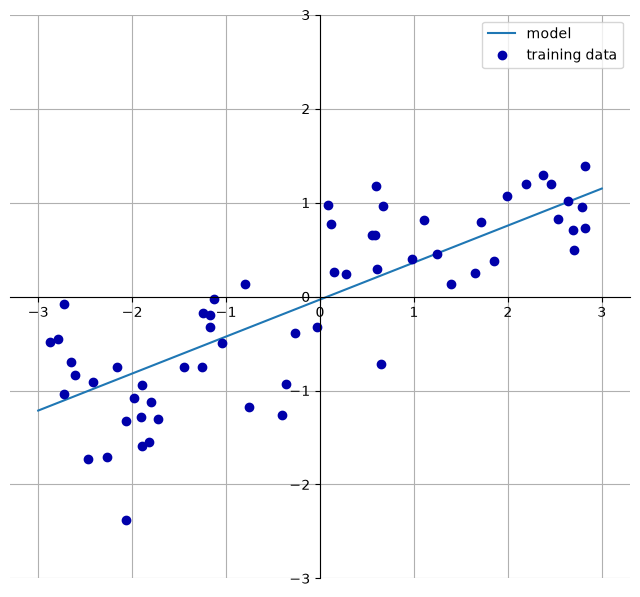

In [78]:
mglearn.plots.plot_linear_regression_wave()

In [79]:
#線形回帰（通常最小二乗法）
from sklearn.linear_model import LinearRegression
x,y = mglearn.datasets.make_wave(n_samples=60)
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    random_state=42
)

lr = LinearRegression().fit(x_train,y_train)

In [80]:
#係数(coefficient)と切片(intercept)の確認
print("Lr.coef_:{}".format(lr.coef_))
print("Lr.intercept_:{}".format(lr.intercept_))

Lr.coef_:[0.39390555]
Lr.intercept_:-0.031804343026759746


In [81]:
#適合不足が起きている
print("Train set score:{:.2f}".format(lr.score(x_train, y_train)))
print("Test set score:{:.2f}".format(lr.score(x_test, y_test)))

Train set score:0.67
Test set score:0.66


In [82]:
#特徴量間の積(交互作用)も含めたデータセットを作成
#過剰適合の例

x,y = mglearn.datasets.load_extended_boston()
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    random_state=0
)

lr = LinearRegression().fit(x_train,y_train)

print("Train set score:{:.2f}".format(lr.score(x_train, y_train)))
print("Test set score:{:.2f}".format(lr.score(x_test, y_test)))


Train set score:0.95
Test set score:0.61


**リッジ回帰**

In [83]:
from sklearn.linear_model import Ridge
ridge = Ridge().fit(x_train,y_train)
print("Train set score:{:.2f}".format(ridge.score(x_train,y_train)))
print("Test set score:{:.2f}".format(ridge.score(x_test,y_test)))

Train set score:0.89
Test set score:0.75


In [84]:
#ハイパーパラメータであるalphaを変更
#alphaを増やすほど係数はより０に近くなる
ridge10 = Ridge(alpha=10).fit(x_train,y_train)
print("Train set score:{:.2f}".format(ridge10.score(x_train,y_train)))
print("Test set score:{:.2f}".format(ridge10.score(x_test,y_test)))

Train set score:0.79
Test set score:0.64


In [85]:
ridge01 = Ridge(alpha=0.1).fit(x_train,y_train)
print("Train set score:{:.2f}".format(ridge01.score(x_train,y_train)))
print("Test set score:{:.2f}".format(ridge01.score(x_test,y_test)))

Train set score:0.93
Test set score:0.77


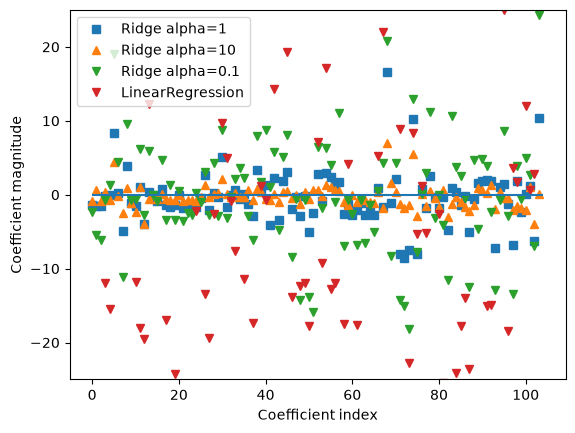

In [86]:
#ハイパーパラメータと係数との関係
plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")

plt.plot(lr.coef_, 'v', label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()
plt.show()

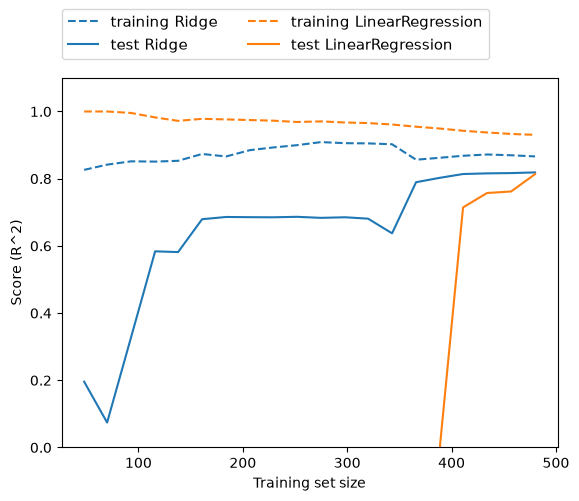

In [87]:
#alphaの値を固定して訓練データセットの量を変化させてみる
#十分な訓練データがる場合には、正則化はあまり重要ではなくなる
mglearn.plots.plot_ridge_n_samples()

**ラッソ回帰**

In [88]:
from sklearn.linear_model import Lasso

lasso = Lasso().fit(x_train,y_train)
print("Training set score:{:.2f}".format(lasso.score(x_train,y_train)))
print("Test set score:{:.2f}".format(lasso.score(x_test,y_test)))
print("Number of features used:{}".format(np.sum(lasso.coef_ != 0))) #NumPyでは True = 1, False = 0 として合計できる

Training set score:0.29
Test set score:0.21
Number of features used:4


In [89]:
#alphaを減らして適合不足を解消したい

lasso001 = Lasso(alpha=0.01,max_iter=1000000).fit(x_train,y_train)
print("Training set score:{:.2f}".format(lasso001.score(x_train,y_train)))
print("Test set score:{:.2f}".format(lasso001.score(x_test,y_test)))
print("Number of features used:{}".format(np.sum(lasso001.coef_ != 0)))

Training set score:0.90
Test set score:0.77
Number of features used:33


In [90]:
#alphaを減らしすぎると過剰適合となり、性能はLinearRegressionと似たようなものになる

lasso00001 = Lasso(alpha=0.0001,max_iter=1000000).fit(x_train,y_train)
print("Training set score:{:.2f}".format(lasso00001.score(x_train,y_train)))
print("Test set score:{:.2f}".format(lasso00001.score(x_test,y_test)))
print("Number of features used:{}".format(np.sum(lasso00001.coef_ != 0)))

Training set score:0.95
Test set score:0.64
Number of features used:96


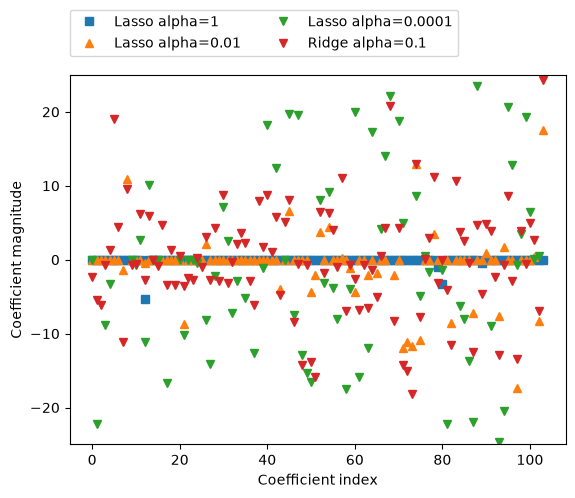

In [91]:
plt.plot(lasso.coef_, 's', label="Lasso alpha=1")
plt.plot(lasso001.coef_, '^', label="Lasso alpha=0.01")
plt.plot(lasso00001.coef_, 'v', label="Lasso alpha=0.0001")

plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")
plt.legend(ncol=2, loc=(0, 1.05))
plt.ylim(-25, 25)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.show()

**ロジスティック回帰とサポートベクタマシン**

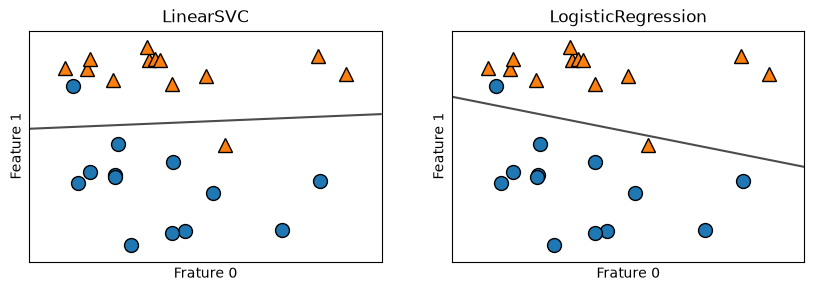

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

x,y = mglearn.datasets.make_forge()

#axes は、Pythonでは特に Matplotlibでグラフを複数扱うときによく見る変数名
#(1,2)は一行二列ののグラフという意味
#fig → 図全体を表す Figure , axes → それぞれのグラフ領域を持つ配列
fig,axes = plt.subplots(1,2,figsize=(10,3))

for model , ax in zip([LinearSVC(),LogisticRegression()],axes):
    clf = model.fit(x,y)
    mglearn.plots.plot_2d_separator(
        clf,
        x,
        fill=False,
        eps=0.5,
        ax=ax,
        alpha=0.7
    )
    
    mglearn.discrete_scatter(
        x[:,0],
        x[:,1],
        y,ax=ax
    )

    ax.set_title("{}".format(clf.__class__.__name__))
    ax.set_xlabel("Frature 0")
    ax.set_ylabel("Feature 1")

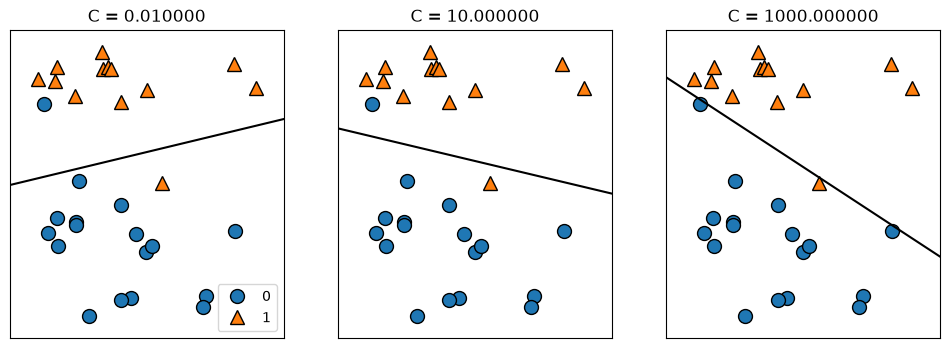

In [93]:
#パラメータCとの関係
#Cが大きくなるほど正則化は「弱く」なり過剰適合になる

mglearn.plots.plot_linear_svc_regularization()

In [94]:
#ロジスティック回帰をcancerデータセットを用いてより詳しく解析していく

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

#stratify=cancer.target は、train_test_split() で訓練データとテストデータのクラス比率を、元データとほぼ同じにするための指定
x_train,x_test,y_train,y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=42
)

logreg = LogisticRegression(max_iter=1000).fit(x_train,y_train)

print("Training set score:{:.3f}".format(logreg.score(x_train,y_train)))
print("Test set score:{:.3f}".format(logreg.score(x_test,y_test)))

Training set score:0.962
Test set score:0.965


c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [95]:
#デフォルトのC=1では訓練セットとテストセットの精度がとても近いため適合不足の可能性があるため、より柔軟なモデルを試す

logreg100 = LogisticRegression(C=100,max_iter=1000).fit(x_train,y_train)

print("Training set score:{:.3f}".format(logreg100.score(x_train,y_train)))
print("Test set score:{:.3f}".format(logreg100.score(x_test,y_test)))

Training set score:0.974
Test set score:0.965


c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [96]:
#強力に正則化してみる
#さらに適合不足になってしまった
logreg0001= LogisticRegression(C=0.001,max_iter=1000).fit(x_train,y_train)

print("Training set score:{:.3f}".format(logreg0001.score(x_train,y_train)))
print("Test set score:{:.3f}".format(logreg0001.score(x_test,y_test)))

Training set score:0.953
Test set score:0.944


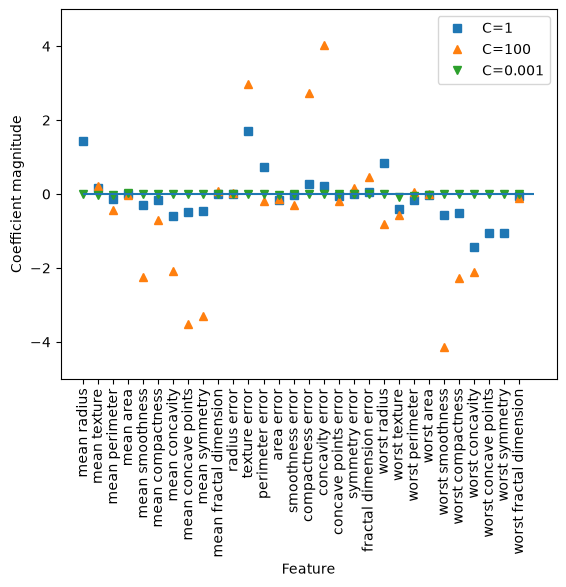

In [97]:
plt.plot(logreg.coef_.T, 's', label="C=1")
plt.plot(logreg100.coef_.T, '^', label="C=100")
plt.plot(logreg0001.coef_.T, 'v', label="C=0.001")

plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.ylim(-5, 5)
plt.xlabel("Feature")
plt.ylabel("Coefficient magnitude")
plt.legend()
plt.show()

c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of p

Training accuracy of l1 logreg with C0.001: 0.91
Test accuracy of l1 logreg with C0.001: 0.92
Training accuracy of l1 logreg with C1.000: 0.96
Test accuracy of l1 logreg with C1.000: 0.96
Training accuracy of l1 logreg with C100.000: 0.99
Test accuracy of l1 logreg with C100.000: 0.98


c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


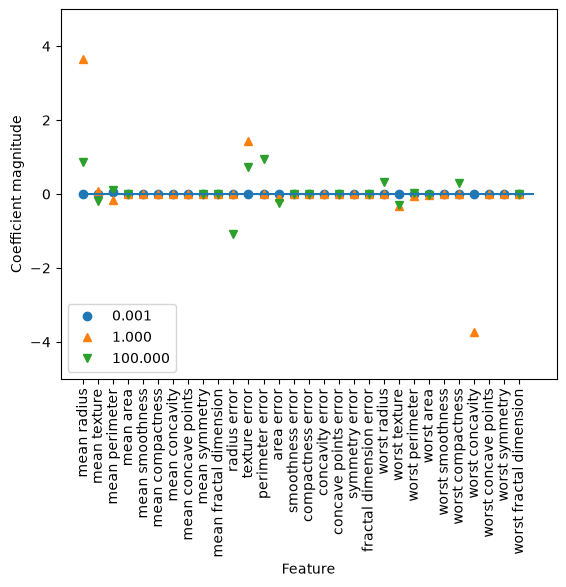

In [98]:
for C, marker in zip([0.001, 1, 100], ['o', '^', 'v']):
    lr_l1 = LogisticRegression(C=C, penalty="l1",solver="liblinear").fit(x_train, y_train)
    print("Training accuracy of l1 logreg with C{:.3f}: {:.2f}".format(C, lr_l1.score(x_train, y_train)))
    print("Test accuracy of l1 logreg with C{:.3f}: {:.2f}".format(C, lr_l1.score(x_test, y_test)))
    plt.plot(lr_l1.coef_.T, marker, label="{:.3f}".format(C))
    
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.xlabel("Feature")
plt.ylabel("Coefficient magnitude")
plt.ylim(-5, 5)
plt.legend(loc=3)
plt.show()


**線形モデルのよる多クラス分類**

Text(0, 0.5, 'Feature 1')

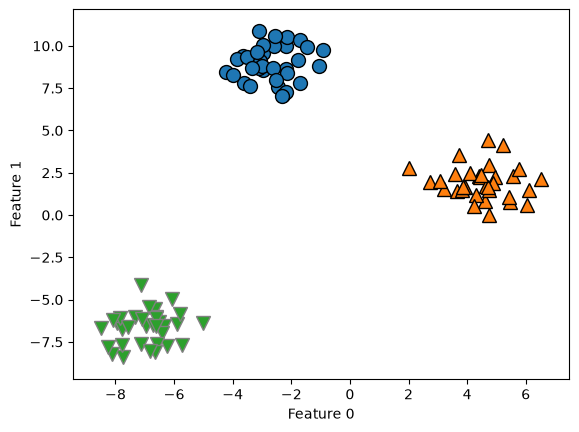

In [99]:
#1対その他手法

from sklearn.datasets import make_blobs

x,y = make_blobs(random_state=42)
mglearn.discrete_scatter(x[:,0],x[:,1],y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

In [100]:
linear_svm = LinearSVC().fit(x,y)
print("Coefficient shape: ",linear_svm.coef_.shape)
print("Intercept shape: ",linear_svm.intercept_.shape)

Coefficient shape:  (3, 2)
Intercept shape:  (3,)


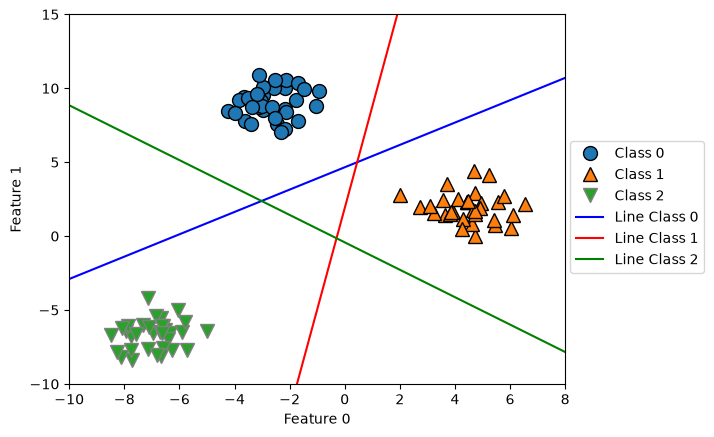

In [101]:
mglearn.discrete_scatter(x[:,0],x[:,1],y)
line = np.linspace(-15,15)

for coef,intercept,color in zip(linear_svm.coef_,linear_svm.intercept_,["b","r","g"]):
    plt.plot(line,
             -(line * coef[0] + intercept) / coef[1],
             c=color
    )

plt.ylim(-10,15)
plt.xlim(-10,8)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line Class 0', 'Line Class 1', 'Line Class 2'], loc=(1.01, 0.3))
plt.show()


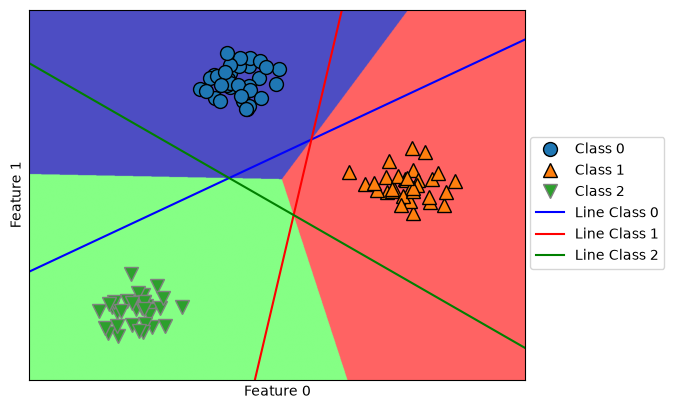

In [102]:
#真ん中の三角形ではどこに分類する？
#その点に最も近い線を持つクラスに分類する

mglearn.plots.plot_2d_classification(linear_svm, x, fill=True, alpha=.7)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
line = np.linspace(-15, 15)

for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_, ['b', 'r', 'g']):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)

plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line Class 0', 'Line Class 1', 'Line Class 2'], loc=(1.01, 0.3))
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()


**ナイーブベイズモデル**

- ナイーブベイズ = 確率を使った分類器
- ベイズの定理がベース
- 特徴量同士は条件付き独立と仮定
- 計算が速い
- 特に文章などの高次元データに使いやすい

**種類**
- BernoulliNB：0/1
- MultinomialNB：回数
- GaussianNB：連続値（正規分布を仮定）

# 決定木

In [103]:
#まずはデフォルトの設定で完全な木を構築する（葉が純粋になるまで木を育てる）
#この場合は過剰適合する

from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()

x_train,x_test,y_train,y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=42
)

tree = DecisionTreeClassifier(random_state=0)
tree.fit(x_train,y_train)

print("Accuracy on training set:{:.3f}".format(tree.score(x_train,y_train)))
print("Accuracy on test set:{:.3f}".format(tree.score(x_test,y_test)))


Accuracy on training set:1.000
Accuracy on test set:0.937


In [104]:
#過剰適合を防ぐために事前枝刈りを実施し、木の深さに制限を付ける
#訓練制度は下がったがテスト制度は向上した

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=0
)
tree.fit(x_train,y_train)

print("Accuracy on training set:{:.3f}".format(tree.score(x_train,y_train)))
print("Accuracy on test set:{:.3f}".format(tree.score(x_test,y_test)))

Accuracy on training set:0.988
Accuracy on test set:0.951


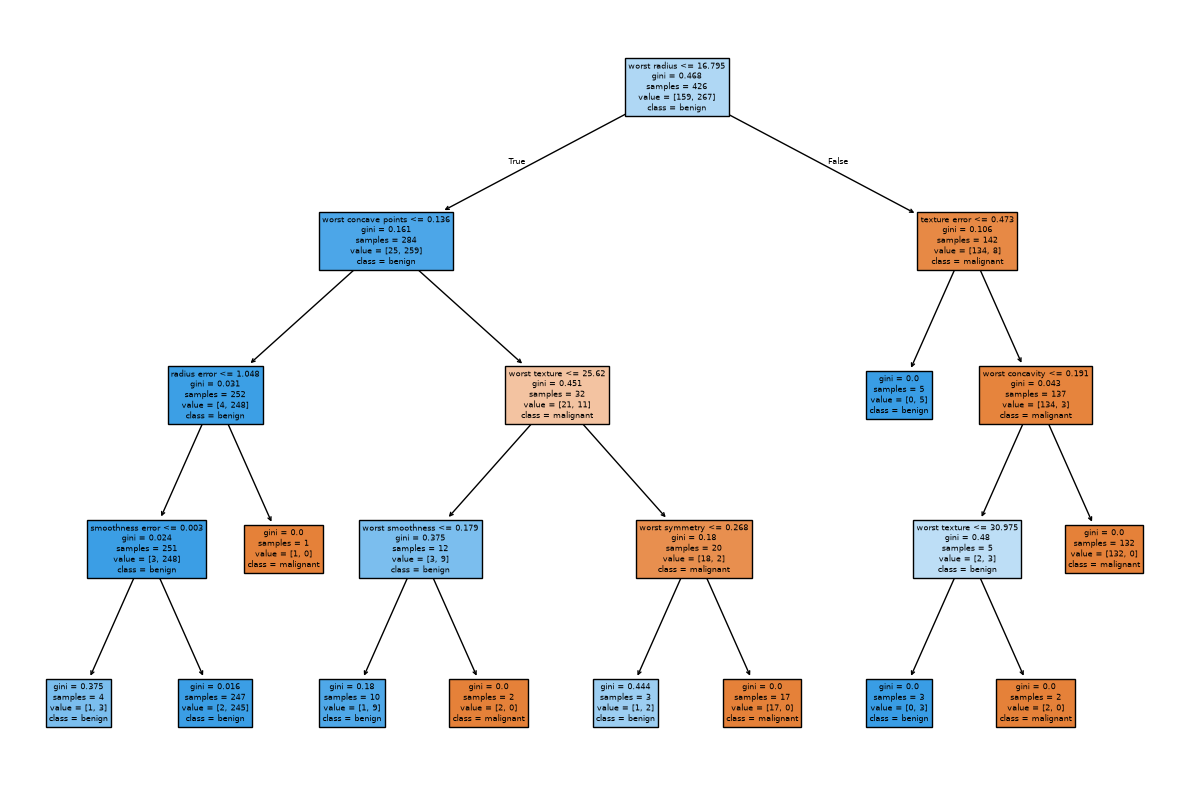

In [105]:
#決定木の解析

from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))

plot_tree(
    tree,
    feature_names=cancer.feature_names,
    class_names=["malignant", "benign"],
    filled=True
)

plt.show()

In [106]:
#特徴量の重要度

print("Feature importances:\n{}".format(tree.feature_importances_))

Feature importances:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01019737 0.04839825
 0.         0.         0.0024156  0.         0.         0.
 0.         0.         0.72682851 0.0458159  0.         0.
 0.0141577  0.         0.018188   0.1221132  0.01188548 0.        ]


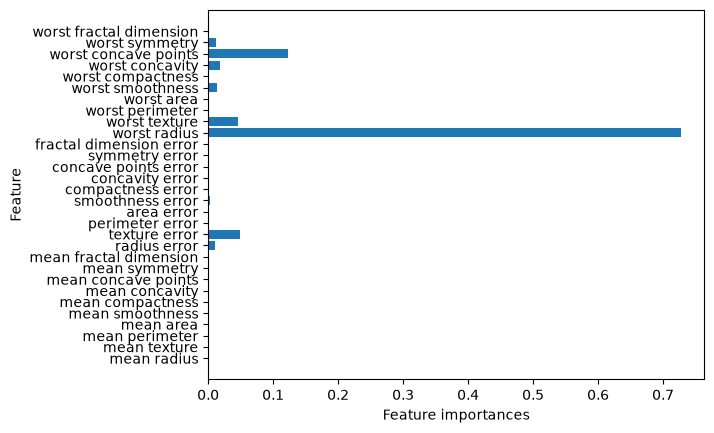

In [107]:
#特徴量の重要度の可視化

def plot_feature_importances_cancer(model):
    n_feature = cancer.data.shape[1]    #特徴量の数
    #barh は **horizontal bar（横棒グラフ）
    plt.barh(range(n_feature),          #range(n_feature)で、棒を置く縦方向の位置を指定
             model.feature_importances_,#棒の長さ
             align="center"
    )
    #plt.yticks([0, 1, 2], ["A", "B", "C"])は「Y軸の tick（目盛り） を0, 1, 2に置いて、そのラベルをA, B, Cにする」という意味で
    plt.yticks(np.arange(n_feature),cancer.feature_names)
    plt.xlabel("Feature importances")
    plt.ylabel("Feature")

plot_feature_importances_cancer(tree)

Feature importances: [0. 1.]


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

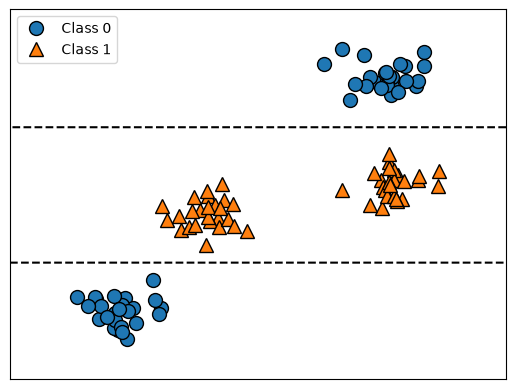

In [108]:
#特徴量とクラスの関係
tree = mglearn.plots.plot_tree_not_monotone()
display(tree)


Text(0, 0.5, 'Price in $/Mbyte')

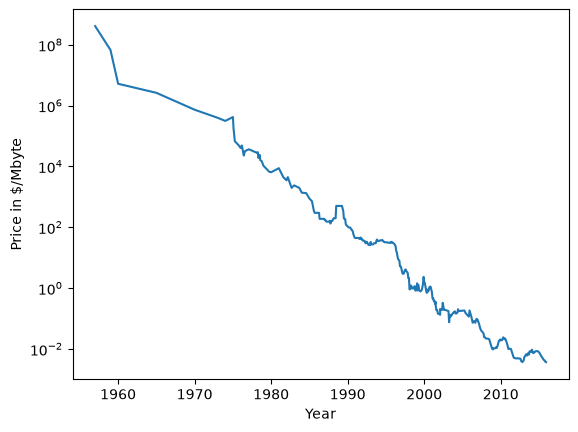

In [109]:
# RAMの価格の変化をプロットする

import os
ram_prices = pd.read_csv(os.path.join(mglearn.datasets.DATA_PATH,"ram_price.csv"))
plt.semilogy(ram_prices.date,ram_prices.price)
plt.xlabel("Year")
plt.ylabel("Price in $/Mbyte")

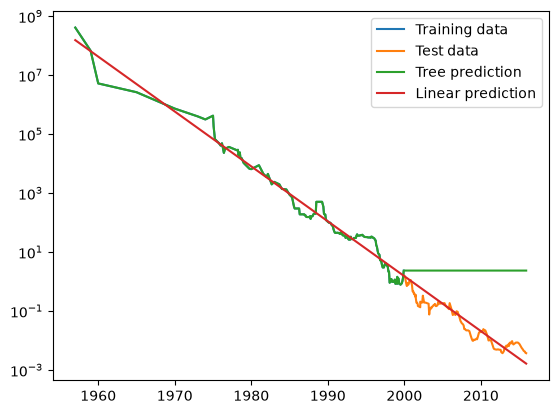

In [110]:
#決定木に基づくすべてのモデルは外挿をするのが苦手

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
import numpy as np

# 過去のデータを用いて2000年以降の価格を予想する
data_train = ram_prices[ram_prices.date < 2000]
data_test = ram_prices[ram_prices.date >= 2000]

# 日付に基づいて価格を予測
#scikit-learnではXを基本的に(サンプル数, 特徴量数)という2次元にする必要がある。
x_train = data_train.date.to_numpy()[:, np.newaxis]

# データとターゲットの関係を単純にするために対数変換
y_train = np.log(data_train.price)

tree = DecisionTreeRegressor().fit(x_train, y_train)
linear_reg = LinearRegression().fit(x_train, y_train)

# 全ての価格を予想
X_all = ram_prices.date.to_numpy()[:, np.newaxis]

pred_tree = tree.predict(X_all)
pred_lr = linear_reg.predict(X_all)

# 対数変換をキャンセルするために逆変換
price_tree = np.exp(pred_tree)
price_lr = np.exp(pred_lr)

#plt.semilogy() は、y軸だけを対数目盛にしてグラフを描く関数
plt.semilogy(data_train.date, data_train.price, label="Training data")
plt.semilogy(data_test.date, data_test.price, label="Test data")
plt.semilogy(ram_prices.date, price_tree, label="Tree prediction")
plt.semilogy(ram_prices.date, price_lr, label="Linear prediction")
plt.legend()
plt.show()

- 決定木のアンサンブル法

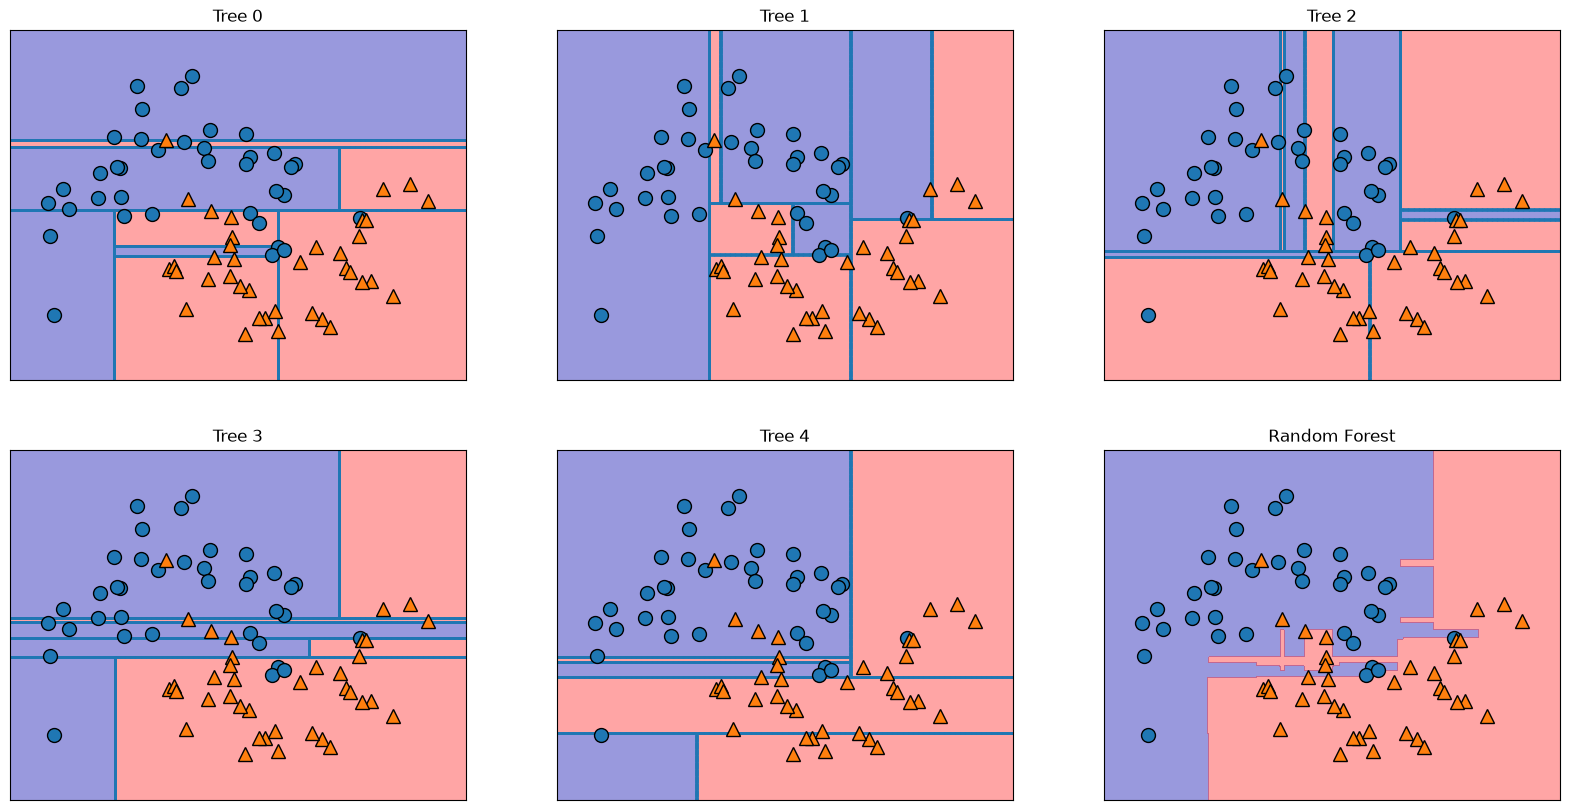

In [111]:
#ランダムフォレストの解析

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

x,y = make_moons(n_samples=100,noise=0.25,random_state=3)
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    stratify=y,
    random_state=42
)

forest = RandomForestClassifier(
    n_estimators=5,
    random_state=2
)

forest.fit(x_train,y_train)

#ランダムフォレストによって行われる集合的な予測を可視化

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

#enumerate() は、リストなどから「番号」と「中身」を同時に取り出すための関数
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title("Tree {}".format(i))
    mglearn.plots.plot_tree_partition(x_train, y_train, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(forest,x_train, fill=True, ax=axes[-1, -1], alpha=.4)
axes[-1, -1].set_title("Random Forest")
mglearn.discrete_scatter(x_train[:, 0],x_train[:, 1], y_train)
plt.show()


In [112]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    random_state=0
)

forest = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)

forest.fit(x_train,y_train)

print("Accuracy on training set:{:.3f}".format(forest.score(x_train,y_train)))
print("Accuracy on test set:{:.3f}".format(forest.score(x_test,y_test)))


Accuracy on training set:1.000
Accuracy on test set:0.972


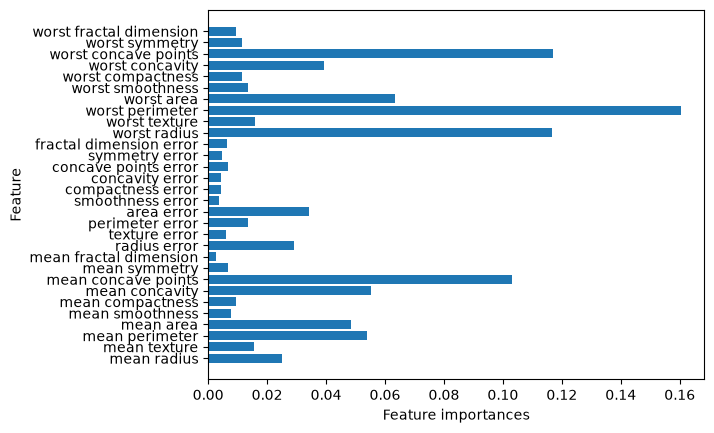

In [113]:
# ランダムフォレストでは多くの特徴量に重要度が分散している
plot_feature_importances_cancer(forest)

In [114]:
#勾配ブースティング回帰木

from sklearn.ensemble import GradientBoostingClassifier

x = cancer.data
y = cancer.target

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    random_state=0
)

gbrt = GradientBoostingClassifier(
    random_state=0
)

gbrt.fit(x_train,y_train)

#訓練セット精度が１００パーセントであるため、おそらく過剰適合している
print("Accuracy on training set:{:.3f}".format(gbrt.score(x_train,y_train)))
print("Accuracy on test set:{:.3f}".format(gbrt.score(x_test,y_test)))

Accuracy on training set:1.000
Accuracy on test set:0.965


In [115]:
#木が複雑すぎる → max_depth を下げる
#ブースティング全体を慎重に学習させたい → learning_rate を下げて n_estimators を増やす

In [116]:
#深さの最大値を制限
gbrt = GradientBoostingClassifier(
    max_depth=1,
    random_state=0
)

gbrt.fit(x_train,y_train)

print("Accuracy on training set:{:.3f}".format(gbrt.score(x_train,y_train)))
print("Accuracy on test set:{:.3f}".format(gbrt.score(x_test,y_test)))

Accuracy on training set:0.991
Accuracy on test set:0.972


In [117]:
#学習率を下げる
gbrt = GradientBoostingClassifier(
    learning_rate=0.01,
    random_state=0
)

gbrt.fit(x_train,y_train)

print("Accuracy on training set:{:.3f}".format(gbrt.score(x_train,y_train)))
print("Accuracy on test set:{:.3f}".format(gbrt.score(x_test,y_test)))


Accuracy on training set:0.988
Accuracy on test set:0.958


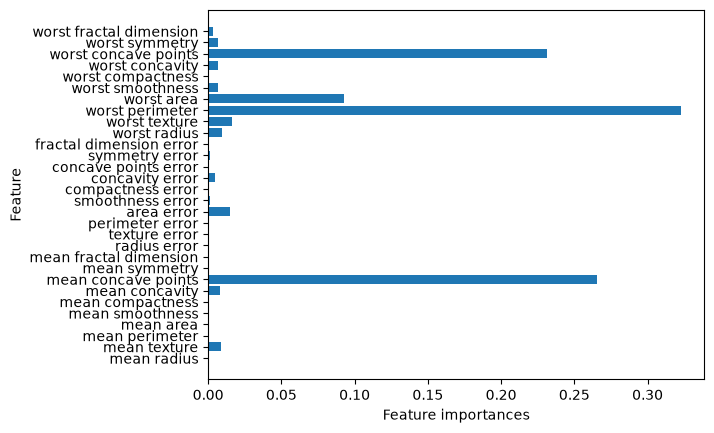

In [118]:
#特徴量の可視化

gbrt = GradientBoostingClassifier(
    max_depth=1,
    random_state=0
)

gbrt.fit(x_train,y_train)

# 勾配ブースティングでは少数の特徴量に重要度が集中している
# 特にmax_depth=1では各木が1回しか分岐できないため、
# 有効な特徴量が繰り返し選択されやすい
plot_feature_importances_cancer(gbrt)

- カーネル法を用いたサポートベクタマシン

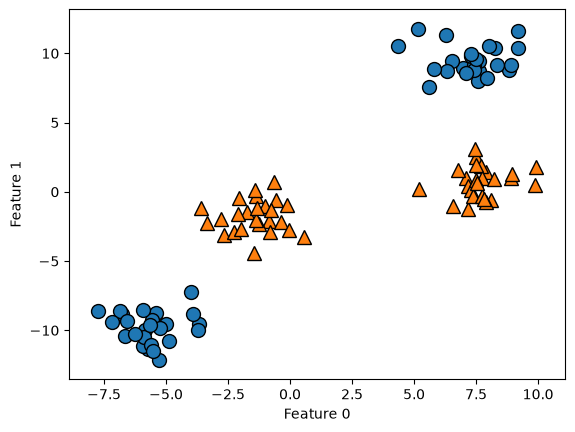

In [119]:
#線形分離が不可能な２クラス分類データセット

x, y = make_blobs(centers=4, random_state=8)
y = y % 2

mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

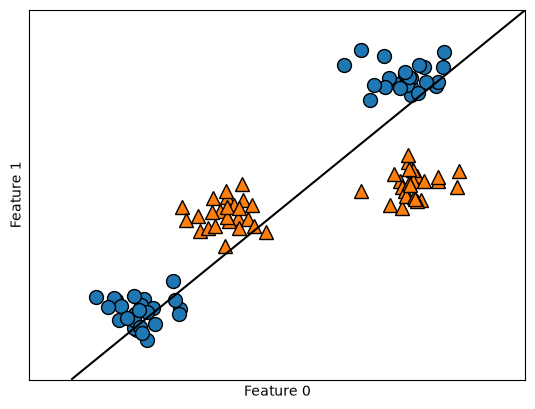

In [ ]:
#線形SVMの決定境界を可視化するが、線形分離が不可能なため、決定境界はデータをうまく分離できない

from sklearn.svm import LinearSVC
linear_svm = LinearSVC().fit(x, y)

mglearn.plots.plot_2d_separator(linear_svm, x)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

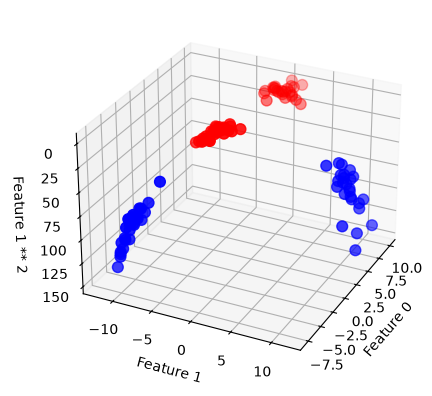

In [122]:
#二番目の特徴量の二乗を追加することで、次元を拡張

X_new = np.hstack([x, x[:, 1:]**2]) #feature1 feature2 に加えて feature ** 2の特徴量が増える。

from mpl_toolkits.mplot3d import Axes3D, axes3d
figure = plt.figure()

ax = figure.add_subplot(
    111,
    projection="3d"
)

ax.view_init(elev=-152, azim=-26)

mask = y == 0

ax.scatter(
    X_new[mask, 0],
    X_new[mask, 1],
    X_new[mask, 2],
    c="b",
    s=60
)

ax.scatter(
    X_new[~mask, 0],
    X_new[~mask, 1],
    X_new[~mask, 2],
    c="r",
    s=60
)

ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.set_zlabel("Feature 1 ** 2")

plt.show()

C:\Users\seita\AppData\Local\Temp\ipykernel_1232\2172386133.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
C:\Users\seita\AppData\Local\Temp\ipykernel_1232\2172386133.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',


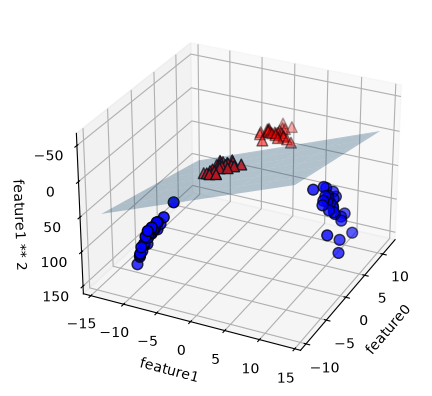

In [124]:
#三次元の線形決定境界を図示

linear_svm_3d = LinearSVC().fit(X_new, y)
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_

figure = plt.figure()
ax = figure.add_subplot(111, projection="3d")
ax.view_init(elev=-152, azim=-26)

xx = np.linspace(X_new[:, 0].min() - 2, X_new[:, 0].max() + 2, 50)
yy = np.linspace(X_new[:, 1].min() - 2, X_new[:, 1].max() + 2, 50)

XX, YY = np.meshgrid(xx, yy)
ZZ = (coef[0] * XX + coef[1] * YY + intercept) / -coef[2]
ax.plot_surface(XX, YY, ZZ, rstride=8, cstride=8, alpha=0.3)
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
           cmap=mglearn.cm2, s=60, edgecolor='k')
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',
           cmap=mglearn.cm2, s=60, edgecolor='k')

ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature1 ** 2")
plt.show()

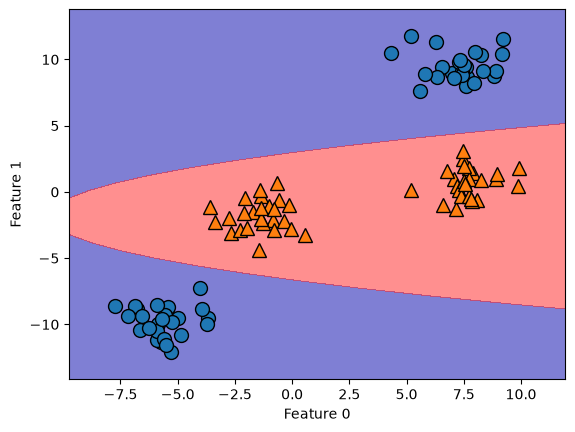

In [125]:
#二次元に戻してみると、線形SVMモデルは線形ではなくなり、楕円に近くなっている

ZZ = YY ** 2
dec = linear_svm_3d.decision_function(np.c_[XX.ravel(), YY.ravel(), ZZ.ravel()])
plt.contourf(XX, YY, dec.reshape(XX.shape), levels=[dec.min(), 0, dec.max()],
             cmap=mglearn.cm2, alpha=0.5)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

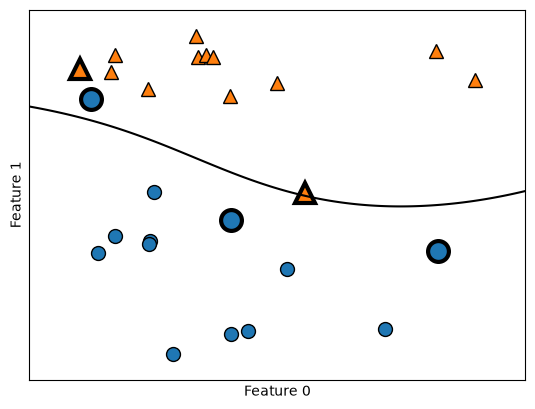

In [ ]:
#RBFカーネルでサポートベクタ―を可視化

from sklearn.svm import SVC

X, y = mglearn.tools.make_handcrafted_dataset()                                                                  
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(X, y)
mglearn.plots.plot_2d_separator(svm, X, eps=.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)

sv = svm.support_vectors_

sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

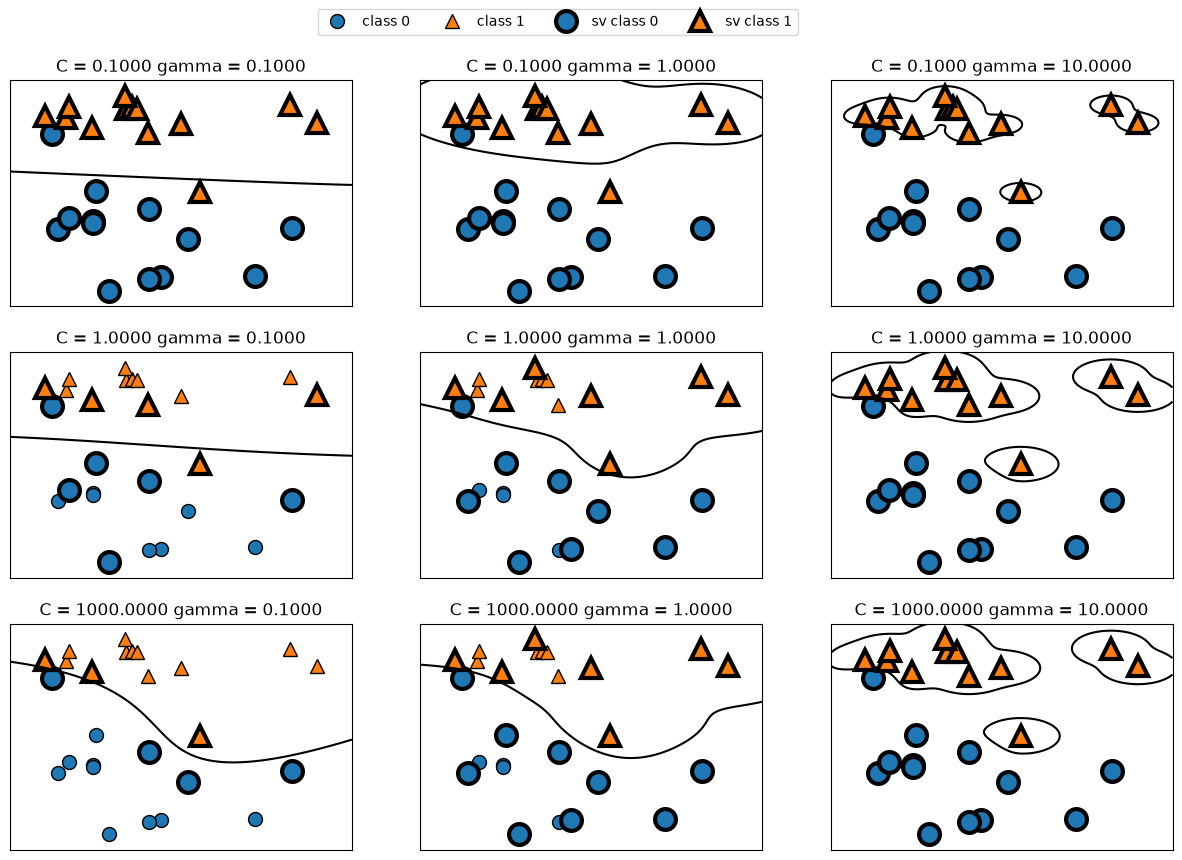

In [ ]:
# gamma：1つの訓練データが影響を与える範囲を調整する
#        大きい → 影響範囲が狭い → 複雑な境界になりやすい
#        小さい → 影響範囲が広い → なめらかな境界になりやすい

# C：誤分類をどれくらい厳しく罰するかを調整する
#    大きい → 誤分類を強く避ける → 複雑になりやすい
#    小さい → 多少の誤分類を許す → 単純になりやすい

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, C in zip(axes, [-1, 0, 3]):
    for a, gamma in zip(ax, range(-1, 2)):
        mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)
        
axes[0, 0].legend(["class 0", "class 1", "sv class 0", "sv class 1"],
                  ncol=4, loc=(.9, 1.2))
plt.show()

In [ ]:
from sklearn.svm import SVC

x = cancer.data
y = cancer.target

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    random_state=0
)

#デフォルトではRBFカーネルで、C=1,  gamma="scale"
svc = SVC(gamma="auto")
svc.fit(x_train,y_train)

print("Accuracy on training set:{:.3f}".format(svc.score(x_train,y_train)))
print("Accuracy on test set:{:.3f}".format(svc.score(x_test,y_test)))


Accuracy on training set:1.000
Accuracy on test set:0.629


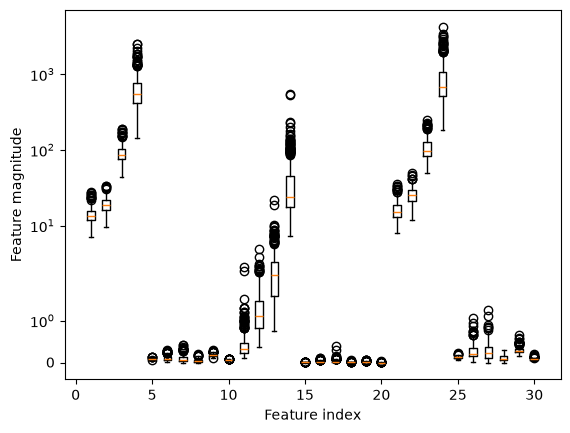

In [ ]:
#cancerデータセットの特徴量は相互にけた違いにサイズが違う
#カーネル法を用いたSVMでは破壊的な影響をもたらす

plt.boxplot(x_train,manage_ticks=False)
plt.xlabel("Feature index")
plt.ylabel("Feature magnitude")
plt.yscale("symlog")
plt.show()

In [ ]:
#SVMのためのデータの前処理
#すべての特徴量をだいたい同じスケールにしたい

#MinMaxScaler

#訓練セットの特徴量ごとに最小値を計算
min_on_training = x_train.min(axis=0)

#訓練セットの特徴量ごとにレンジ(最大値 - 最小値)を計算
range_on_training = x_train.max(axis=0) - min_on_training

#最小値を引いてレンジで割る
#個々の特徴量はmin=0,max=1になる
x_train_scaled = (x_train - min_on_training) / range_on_training

print("Minimum for each feature\n{}".format(x_train_scaled.min(axis=0)))
print("Maximum for each feature\n{}".format(x_train_scaled.max(axis=0)))

Minimum for each feature
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Maximum for each feature
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [ ]:
#テストセットに対しても、まったく同じ変換を行う
x_test_scaled = (x_test - min_on_training) / range_on_training

In [ ]:
svc = SVC(gamma="auto")
svc.fit(x_train_scaled,y_train)

print("Accuracy on training set:{:.3f}".format(svc.score(x_train_scaled,y_train)))
print("Accuracy on test set:{:.3f}".format(svc.score(x_test_scaled,y_test)))

Accuracy on training set:0.948
Accuracy on test set:0.951


In [ ]:
# C 大きい
#   → 誤分類をなるべく許さない
#   → 各訓練データに合わせようとする
#   → 複雑な境界になりやすい
#   → 正則化が弱い

svc = SVC(C=1000,gamma="auto")
svc.fit(x_train_scaled,y_train)

print("Accuracy on training set:{:.3f}".format(svc.score(x_train_scaled,y_train)))
print("Accuracy on test set:{:.3f}".format(svc.score(x_test_scaled,y_test)))

Accuracy on training set:0.988
Accuracy on test set:0.972


## ニュートラルネットワーク(ディープラーニング)

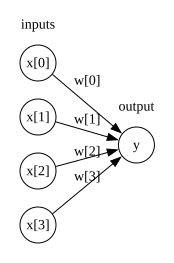

In [ ]:
display(mglearn.plots.plot_logistic_regression_graph())

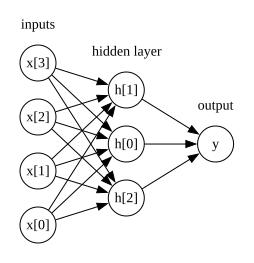

In [ ]:
#一層の隠れ層を持つ多層パーセプトロン
display(mglearn.plots.plot_single_hidden_layer_graph())

Text(0, 0.5, 'relu(x),tanh(x)')

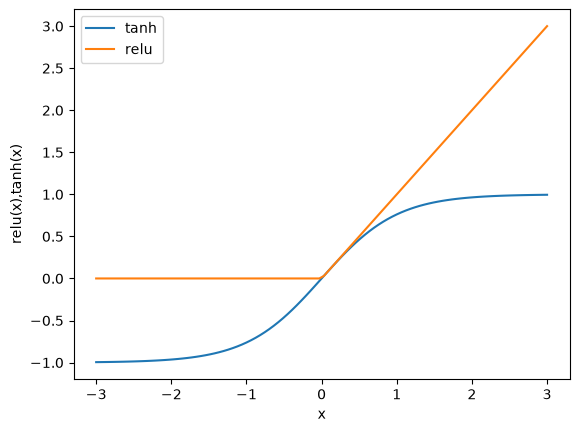

In [ ]:
#活性化関数の可視化

line = np.linspace(-3,3,100)
plt.plot(line,np.tanh(line),label = "tanh")
plt.plot(line,np.maximum(line,0),label = "relu")
plt.legend(loc="best")
plt.xlabel("x")
plt.ylabel("relu(x),tanh(x)")

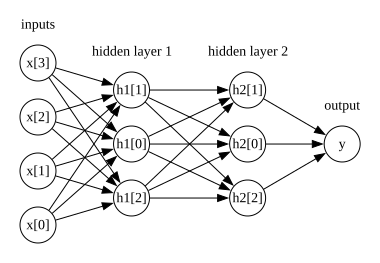

In [ ]:
#隠れ層を追加
display(mglearn.plots.plot_two_hidden_layer_graph())

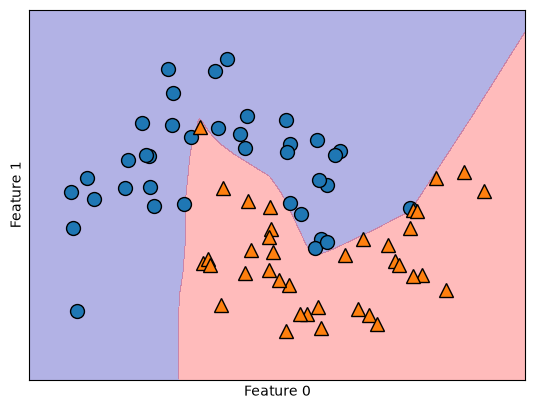

In [ ]:
#ニュートラルネットワークのチューニング

from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons

x,y = make_moons(
    n_samples=100,
    noise=0.25,
    random_state=3
)

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    stratify=y,
    random_state=42
)

#デフォルトでは100隠れユニット
#デフォルトの活性化関数は ReLU
mlp = MLPClassifier(
    solver="lbfgs",
    random_state=0
).fit(x_train,y_train)

mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()



c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


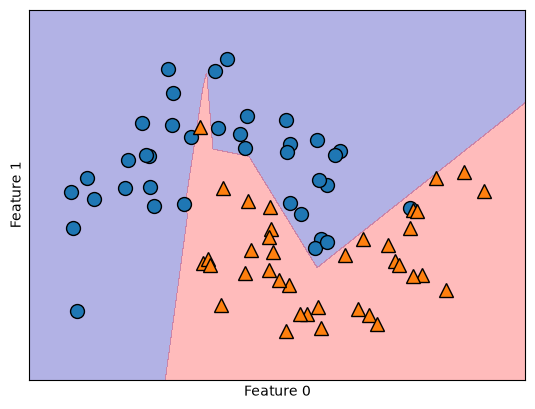

In [ ]:
#隠れユニットの数を減らし、モデルの複雑さを減らす

mlp = MLPClassifier(
    solver="lbfgs",
    random_state=0,
    hidden_layer_sizes=[10]
).fit(x_train,y_train)

mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()


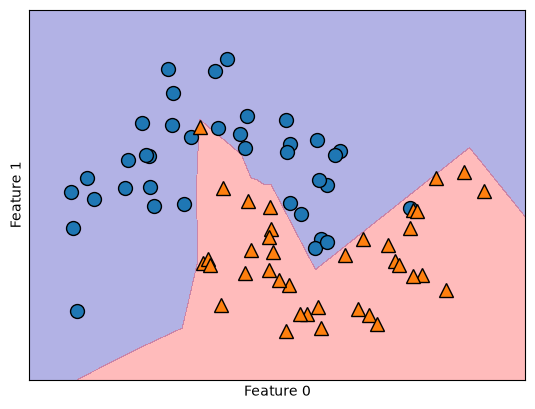

In [ ]:
#それぞれの１０ユニットの隠れ層を２層使う

mlp = MLPClassifier(
    solver="lbfgs",
    random_state=0,
    hidden_layer_sizes=[10,10]
)
mlp.fit(x_train,y_train)

mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()



c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


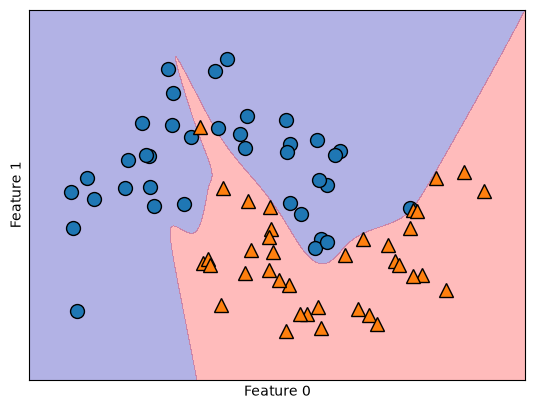

In [ ]:
#それぞれ１０ユニットの隠れ層を２層使う、さらに非線形活性化関数にtanhを使う

mlp = MLPClassifier(
    solver="lbfgs",
    activation="tanh",
    random_state=0,
    hidden_layer_sizes=[10,10]
)
mlp.fit(x_train,y_train)

mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


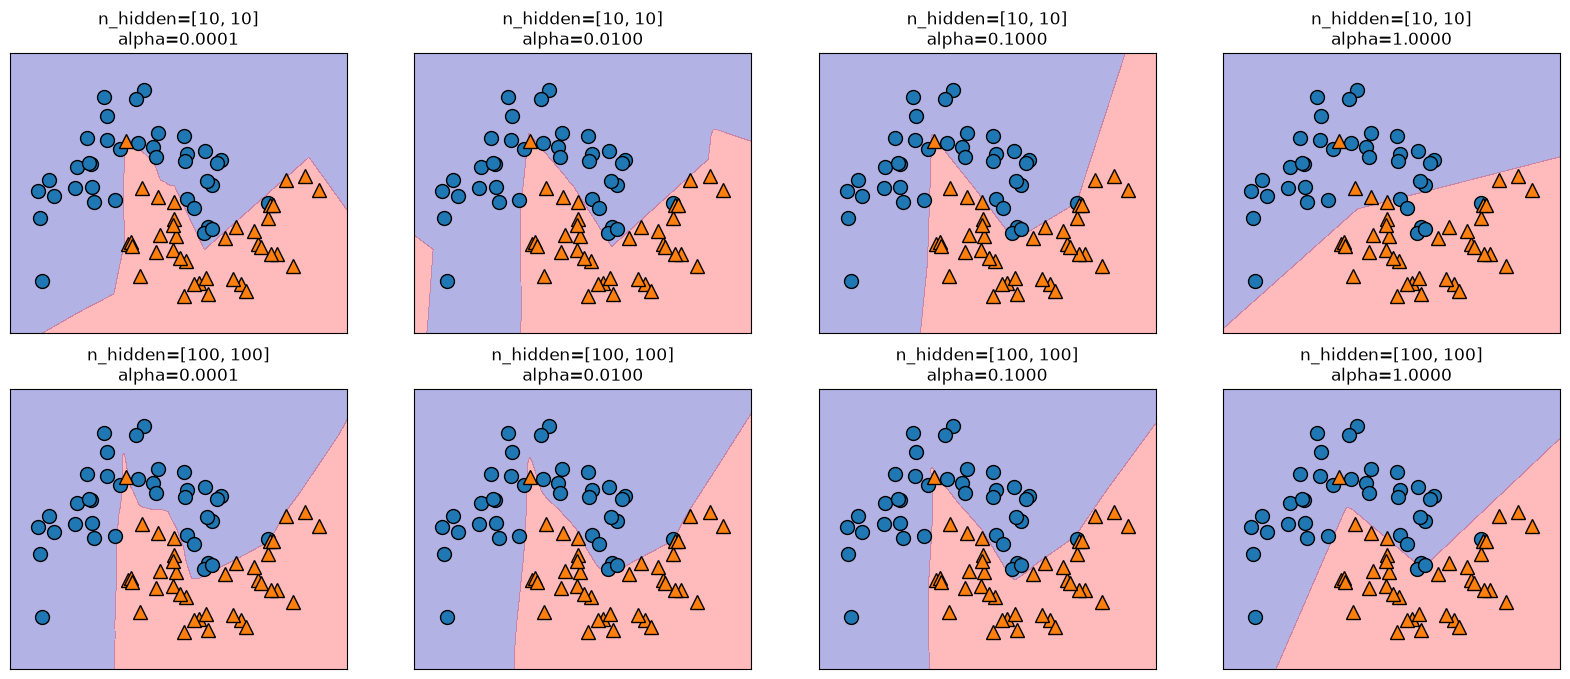

In [ ]:
#様々な隠れユニット数とalpha(正則化)パラメータに対する決定境界

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for axx, n_hidden_nodes in zip(axes, [10, 100]):
    for ax, alpha in zip(axx, [0.0001, 0.01, 0.1, 1]):
        mlp = MLPClassifier(solver='lbfgs', random_state=0,
                            hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes],
                            alpha=alpha)
        mlp.fit(x_train, y_train)
        mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3, ax=ax)
        mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train, ax=ax)
        ax.set_title("n_hidden=[{}, {}]\nalpha={:.4f}".format(
                      n_hidden_nodes, n_hidden_nodes, alpha))

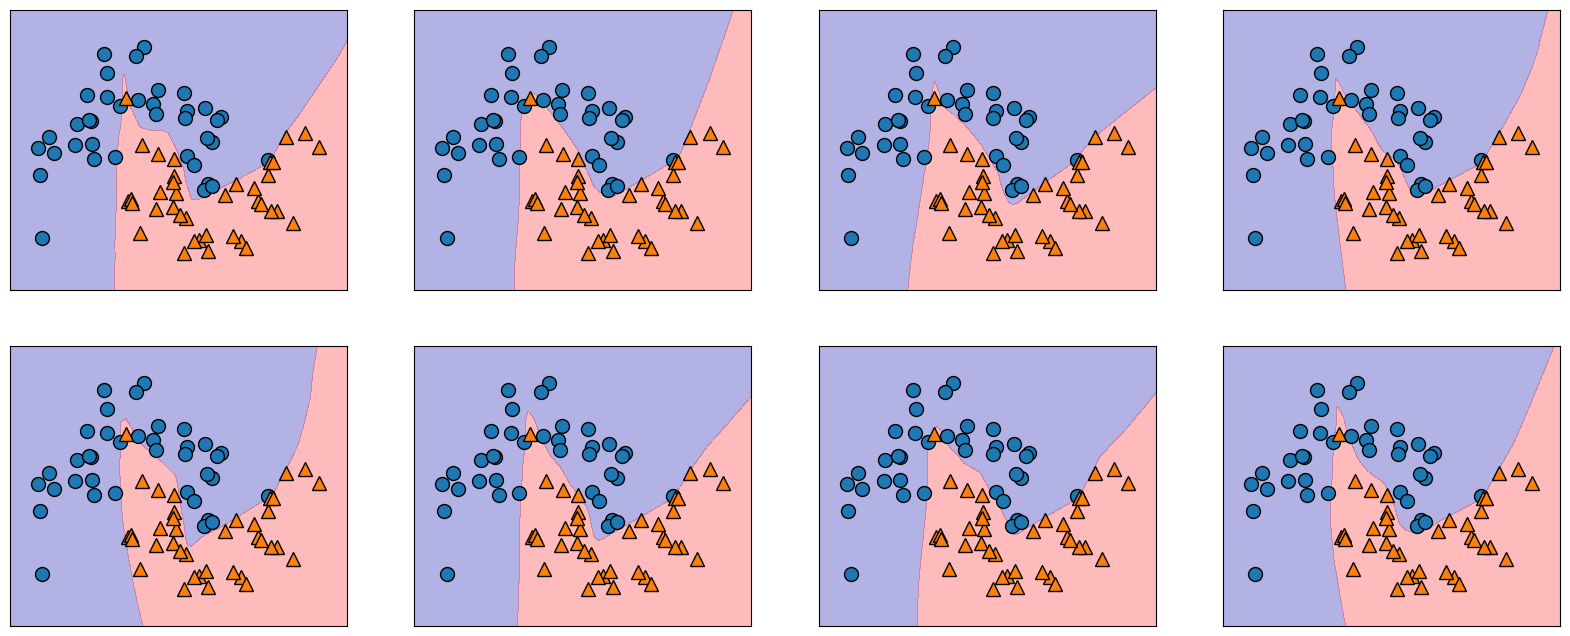

In [ ]:
#同じパラメータだが異なる乱数で初期化された状態から学習された様々な決定境界

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, ax in enumerate(axes.ravel()):
    mlp = MLPClassifier(solver='lbfgs', random_state=i,
                        hidden_layer_sizes=[100, 100])
    mlp.fit(x_train, y_train)
    mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3, ax=ax)
    mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train, ax=ax)
plt.show()

**cancerデータセットに対してMLPClassierを適用してみる**

In [ ]:
#cancerデータセットの各特徴量の最大値
print("Cancer data per-feature maxima:\n{})".format(cancer.data.max(axis=0)))

Cancer data per-feature maxima:
[2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01])


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=0
)

mlp = MLPClassifier(random_state=42)
mlp.fit(x_train,y_train)

print("Accuracy on traning set:{:.2f}".format(mlp.score(x_train,y_train)))
print("Accuracy on test set:{:.2f}".format(mlp.score(x_test,y_test)))

Accuracy on traning set:0.94
Accuracy on test set:0.92


In [ ]:
#ニュートラルネットワークもSVCと同様に、全ての入力特徴量が同じ範囲に長合っていることを仮定している
#理想的には平均が０で分散が１であることが望ましい

mean_on_train = x_train.mean(axis=0)
std_on_train = x_train.std(axis=0)
x
X_train_scaled = (x_train - mean_on_train) / std_on_train
X_test_scaled = (x_test - mean_on_train) / std_on_train

mlp = MLPClassifier(random_state=0)
mlp.fit(X_train_scaled, y_train)

print("Accuracy on training set: {:.3f}".format(mlp.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

Accuracy on training set: 0.991
Accuracy on test set: 0.965


c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
#訓練性能とテスト性能に差があるということは、モデルの複雑さを下げれば汎化性能が上がる可能性があることを意味する
#alphaパラメータを0.0001から1に変えてみる

mlp = MLPClassifier(max_iter=10000,alpha=1,random_state=0)
mlp.fit(X_train_scaled, y_train)

print("Accuracy on training set: {:.3f}".format(mlp.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

Accuracy on training set: 0.988
Accuracy on test set: 0.972


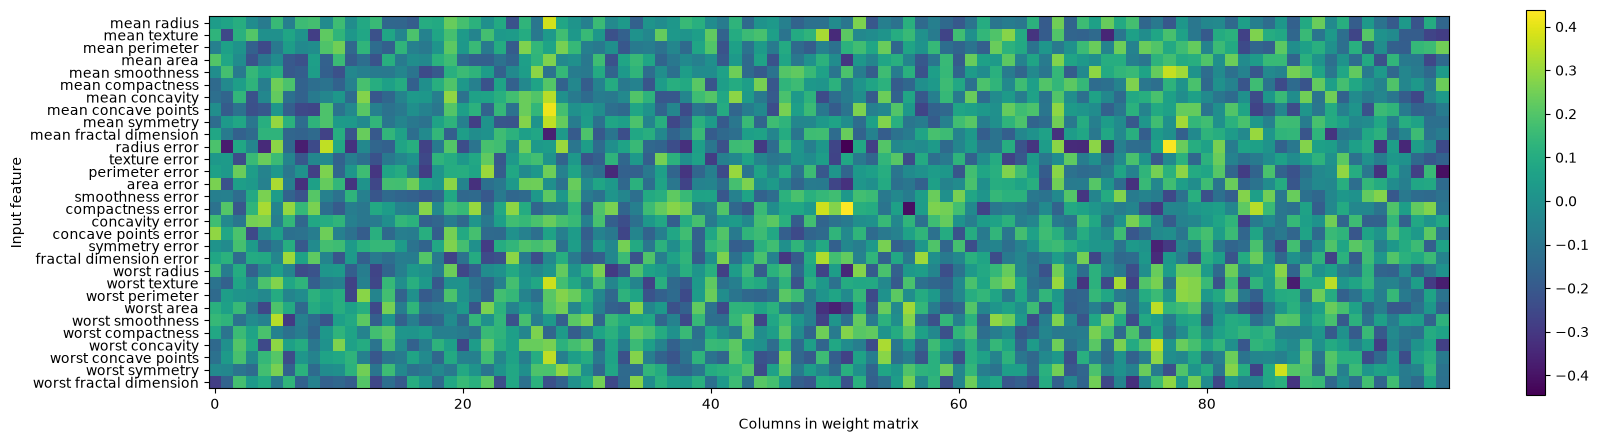

In [ ]:
#重みを見るが、分かりにくい

plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(30), cancer.feature_names)
plt.xlabel("Columns in weight matrix")
plt.ylabel("Input feature")
plt.colorbar()
plt.show()